In [49]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
from pathlib import Path

DATA = Path("../data/complex_facility/Images")
SF6_PATH = Path("../data/sf6_ext.txt")
IMG_IDX = "0010"

In [50]:
img = envi.open(DATA / f"MakoSpectrometer-t{IMG_IDX}.img.hdr")
cube = np.asarray(img.load())  # (128, 128, 128)
wavelengths = np.array(img.bands.centers)

print(cube.shape, cube.dtype)
print(f"value range: {cube.min():.4f} - {cube.max():.4f}")

(128, 128, 128) float32
value range: 0.0005 - 0.0017


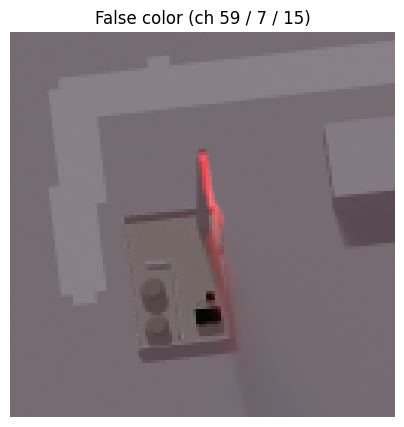

In [51]:
rgb = np.stack([cube[:, :, 59], cube[:, :, 7], cube[:, :, 15]], axis=-1)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.axis("off")
plt.title("False color (ch 59 / 7 / 15)")
plt.show()

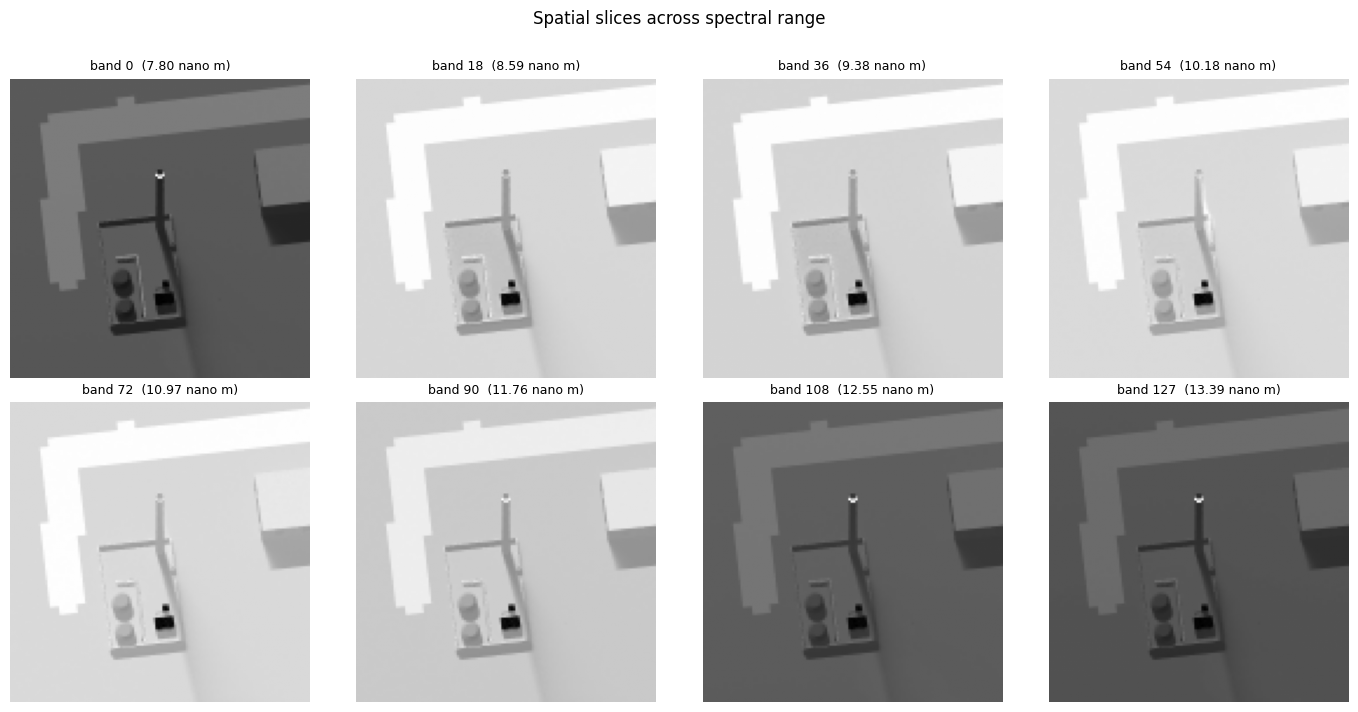

In [53]:
# spatial slices
band_indices = np.linspace(0, cube.shape[2] - 1, 8, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, b in zip(axes.flat, band_indices):
    band_img = cube[:, :, b]
    ax.imshow(band_img, cmap="grey")
    ax.set_title(f"band {b}  ({wavelengths[b]:.2f} nano m)", fontsize=9)
    ax.axis("off")
plt.suptitle("Spatial slices across spectral range", y=1.01)
plt.tight_layout()
plt.show()

[np.float32(0.0010596602), np.float32(0.0009807579), np.float32(0.00088823267)]


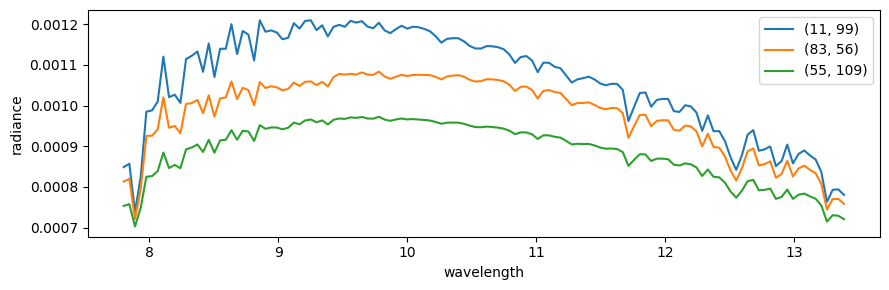

In [54]:
# Spectral curve at a random pixel
rng = np.random.default_rng(42)
pixels_rc = rng.integers(0, 128, size=(3, 2))
print([cube[r, c, :].mean() for r, c in pixels_rc])

plt.figure(figsize=(9, 3))
for row, col in pixels_rc:
    plt.plot(wavelengths, cube[row, col, :], label=f"({row}, {col})")
plt.xlabel("wavelength")
plt.ylabel("radiance")
plt.legend()
plt.tight_layout()
plt.show()

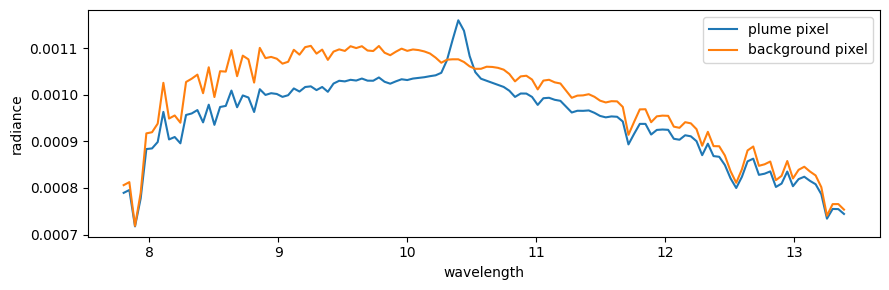

In [68]:
plume_px = cube[70, 70, :]  # pixel roughly in the plume
bg_px = cube[100, 10, :]  # background pixel

plt.figure(figsize=(9, 3))
plt.plot(wavelengths, plume_px, label="plume pixel")
plt.plot(wavelengths, bg_px, label="background pixel")
plt.xlabel("wavelength")
plt.ylabel("radiance")
plt.legend()
plt.tight_layout()
plt.show()

['Scene ENU X Coordinate [m]', 'Scene ENU Y Coordinate [m]', 'Scene ENU Z Coordinate [m]', 'Distance [m]', 'View Angle Cosine', 'Texture U Coordinate', 'Texture V Coordinate', 'Path Transmission', 'Path Radiance', 'Temperature [K]']
(128, 128, 10)


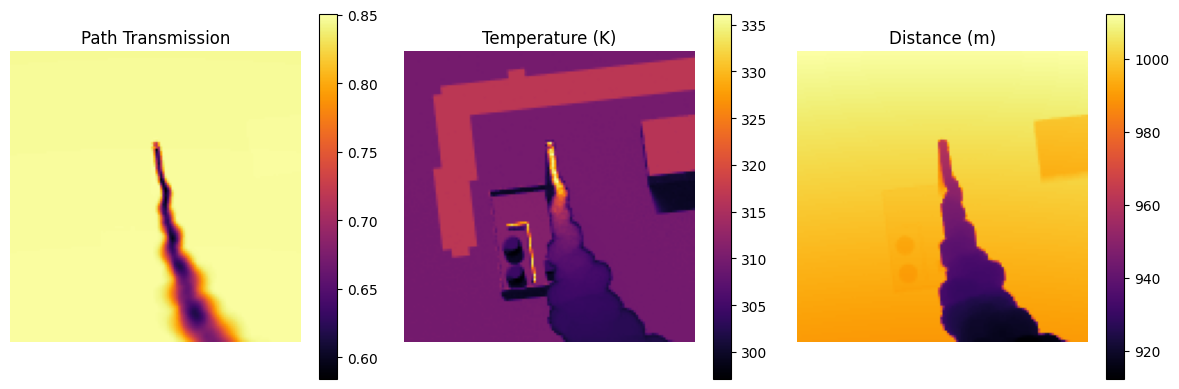

In [70]:
truth = envi.open(DATA / f"truth-t{IMG_IDX}.img.hdr").load()  # (128, 128, 10)
print(truth.metadata["band names"])
print(truth.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, band, title in zip(
    axes, [7, 9, 3], ["Path Transmission", "Temperature (K)", "Distance (m)"]
):
    im = ax.imshow(truth[:, :, band], cmap="inferno")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()